# AI in Cybersecurity (ICT4416) — Internal Assessment 4
## Network Intrusion Detection System (NIDS) using the UNSW-NB15 Dataset

**Binary Classification: Normal vs. Attack**

---
### Table of Contents
1. [Setup & Imports](#1)
2. [Load Data](#2)
3. [Exploratory Data Analysis (EDA)](#3)
4. [Data Preprocessing](#4)
5. [Model Training](#5)
6. [Model Evaluation](#6)
7. [Deep Neural Network](#7)
8. [Comparison & Conclusions](#8)

## 1. Setup & Imports <a id='1'></a>

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    fbeta_score, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, auc
)

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Class-imbalance
from imblearn.over_sampling import SMOTE

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
print('All libraries loaded successfully.')

All libraries loaded successfully.


## 2. Load Data <a id='2'></a>

In [2]:
TRAIN_PATH = 'UNSW_NB15_train_40k.csv'
TEST_PATH  = 'UNSW_NB15_test_10k.csv'

train_raw = pd.read_csv(TRAIN_PATH)
test_raw  = pd.read_csv(TEST_PATH)

print(f'Training set : {train_raw.shape[0]:,} rows x {train_raw.shape[1]} columns')
print(f'Testing  set : {test_raw.shape[0]:,} rows x {test_raw.shape[1]} columns')
train_raw.head()

Training set : 40,000 rows x 16 columns
Testing  set : 10,000 rows x 16 columns


,proto,state,service,dur,sbytes,dbytes,spkts,dpkts,sload,dload,sttl,dttl,smean,dmean,sinpkt,label
0,pri-enc,INT,-,0.000009,200,0,2,0,8.888889e+07,0.000000e+00,254,0,100,0,0.009000,1
1,tcp,FIN,-,0.049860,3926,57474,66,68,6.204572e+05,9.086081e+06,31,29,59,845,0.761846,0
2,tcp,FIN,-,0.998910,608,646,10,10,4.388784e+03,4.661081e+03,254,252,61,65,110.990000,1
3,tcp,FIN,smtp,0.595864,37492,3172,52,38,4.936831e+05,4.147255e+04,31,29,721,83,11.676843,0
4,udp,INT,-,0.000009,104,0,2,0,4.622222e+07,0.000000e+00,254,0,52,0,0.009000,0


## 3. Exploratory Data Analysis (EDA) <a id='3'></a>

### 3.1 Dataset Structure

In [3]:
print('=== Data Types ===')
print(train_raw.dtypes)
print()
print('=== Missing Values (Training) ===')
print(train_raw.isnull().sum())
print()
print('=== Summary Statistics ===')
train_raw.describe()

=== Data Types ===
proto          str
state          str
service        str
dur        float64
sbytes       int64
dbytes       int64
spkts        int64
dpkts        int64
sload      float64
dload      float64
sttl         int64
dttl         int64
smean        int64
dmean        int64
sinpkt     float64
label        int64
dtype: object

=== Missing Values (Training) ===
proto      0
state      0
service    0
dur        0
sbytes     0
dbytes     0
spkts      0
dpkts      0
sload      0
dload      0
sttl       0
dttl       0
smean      0
dmean      0
sinpkt     0
label      0
dtype: int64

=== Summary Statistics ===


,dur,sbytes,dbytes,spkts,dpkts,sload,dload,sttl,dttl,smean,dmean,sinpkt,label
count,40000.000000,4.000000e+04,4.000000e+04,40000.000000,40000.000000,4.000000e+04,4.000000e+04,40000.00000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,1.181550,6.409099e+03,2.471327e+04,26.478525,30.275575,4.572907e+07,1.471366e+06,121.09915,70.684150,140.207025,198.178100,2068.309464,0.300000
std,5.715719,1.252525e+05,1.708381e+05,106.980146,129.778977,1.750041e+08,3.451494e+06,108.93431,97.926862,198.910097,305.898615,10659.913291,0.458263
min,0.000000,4.600000e+01,0.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00,0.00000,0.000000,28.000000,0.000000,0.000000,0.000000
25%,0.000010,1.460000e+02,0.000000e+00,2.000000,0.000000,1.244276e+04,0.000000e+00,31.00000,0.000000,57.000000,0.000000,0.009000,0.000000
50%,0.026797,8.100000e+02,3.200000e+02,10.000000,6.000000,5.179283e+05,1.507469e+04,31.00000,29.000000,73.000000,78.000000,1.165287,0.000000
75%,0.647432,2.558000e+03,3.380000e+03,22.000000,22.000000,4.667234e+06,6.872587e+05,254.00000,29.000000,117.000000,136.000000,55.519361,1.000000
max,59.999989,1.202983e+07,1.465555e+07,9094.000000,10974.000000,5.988000e+09,2.235302e+07,255.00000,254.000000,1504.000000,1458.000000,84371.496000,1.000000


### 3.2 Class Distribution

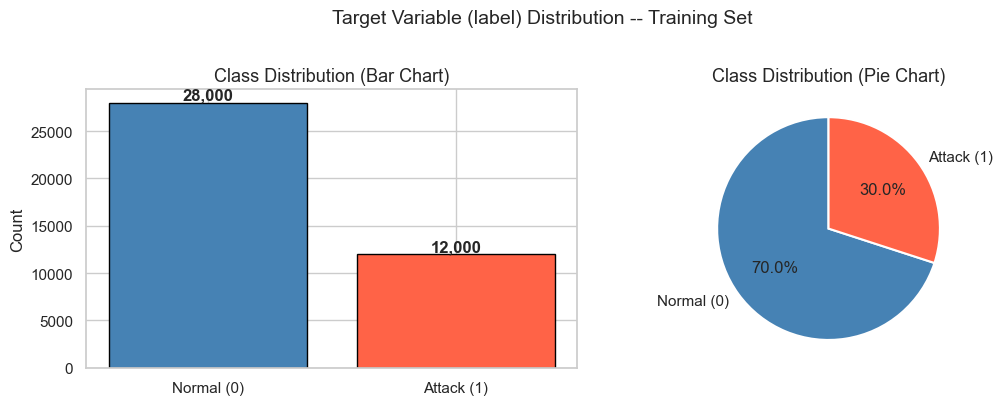

Class Imbalance Ratio  Normal : Attack = 28,000 : 12,000  (70.0% vs 30.0%)


In [4]:
class_counts = train_raw['label'].value_counts()
class_labels = ['Normal (0)', 'Attack (1)']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
axes[0].bar(class_labels, class_counts.values, color=['steelblue', 'tomato'], edgecolor='black')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 300, f'{v:,}', ha='center', fontweight='bold')
axes[0].set_title('Class Distribution (Bar Chart)', fontsize=13)
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(class_counts.values, labels=class_labels, autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Class Distribution (Pie Chart)', fontsize=13)

plt.suptitle('Target Variable (label) Distribution -- Training Set', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('Class Imbalance Ratio  Normal : Attack =',
      f'{class_counts[0]:,} : {class_counts[1]:,}  ({class_counts[0]/len(train_raw)*100:.1f}% vs {class_counts[1]/len(train_raw)*100:.1f}%)')

**Interpretation:** The dataset exhibits moderate class imbalance: 70% Normal traffic vs 30% Attack. This needs to be addressed during preprocessing to prevent models from being biased toward the majority class.

### 3.3 Categorical Feature Analysis

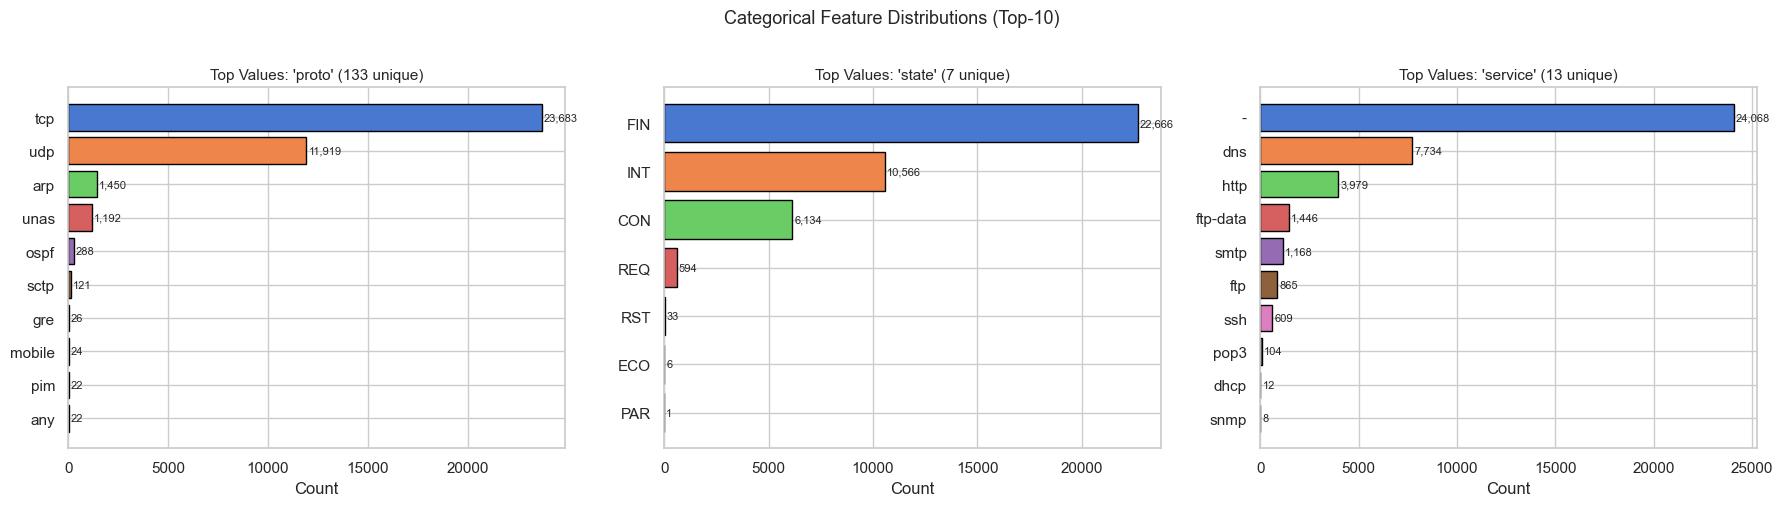

In [5]:
cat_cols = ['proto', 'state', 'service']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, cat_cols):
    top = train_raw[col].value_counts().head(10)
    colors = sns.color_palette('muted', len(top))
    bars = ax.barh(top.index[::-1], top.values[::-1], color=colors[::-1], edgecolor='black')
    for bar, val in zip(bars, top.values[::-1]):
        ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontsize=8)
    ax.set_title(f"Top Values: '{col}' ({train_raw[col].nunique()} unique)", fontsize=11)
    ax.set_xlabel('Count')

plt.suptitle('Categorical Feature Distributions (Top-10)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

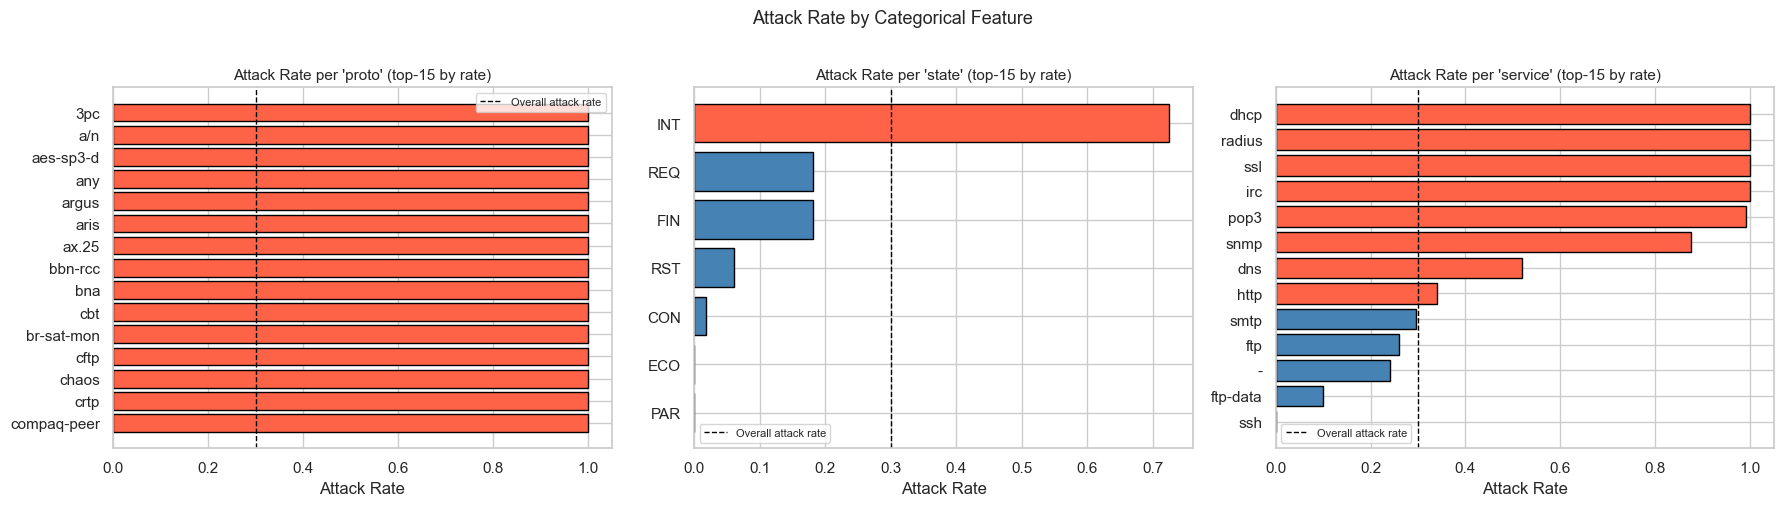

In [6]:
# Attack rate per categorical value
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, cat_cols):
    attack_rate = train_raw.groupby(col)['label'].mean().sort_values(ascending=False).head(15)
    colors = ['tomato' if v > 0.3 else 'steelblue' for v in attack_rate.values]
    ax.barh(attack_rate.index[::-1], attack_rate.values[::-1], color=colors[::-1], edgecolor='black')
    ax.axvline(0.3, color='black', linestyle='--', linewidth=1, label='Overall attack rate')
    ax.set_title(f"Attack Rate per '{col}' (top-15 by rate)", fontsize=11)
    ax.set_xlabel('Attack Rate')
    ax.legend(fontsize=8)

plt.suptitle('Attack Rate by Categorical Feature', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Interpretation:**
- **proto**: TCP and UDP dominate; some less-common protocols show very high attack rates, making `proto` a useful discriminator.
- **state**: `FIN` and `CON` are most frequent; certain states are strongly correlated with attacks.
- **service**: Most traffic has no specific service (`-`); DNS and HTTP are the most common named services.

### 3.4 Numerical Feature Distributions

Numerical features: ['dur', 'sbytes', 'dbytes', 'spkts', 'dpkts', 'sload', 'dload', 'sttl', 'dttl', 'smean', 'dmean', 'sinpkt']


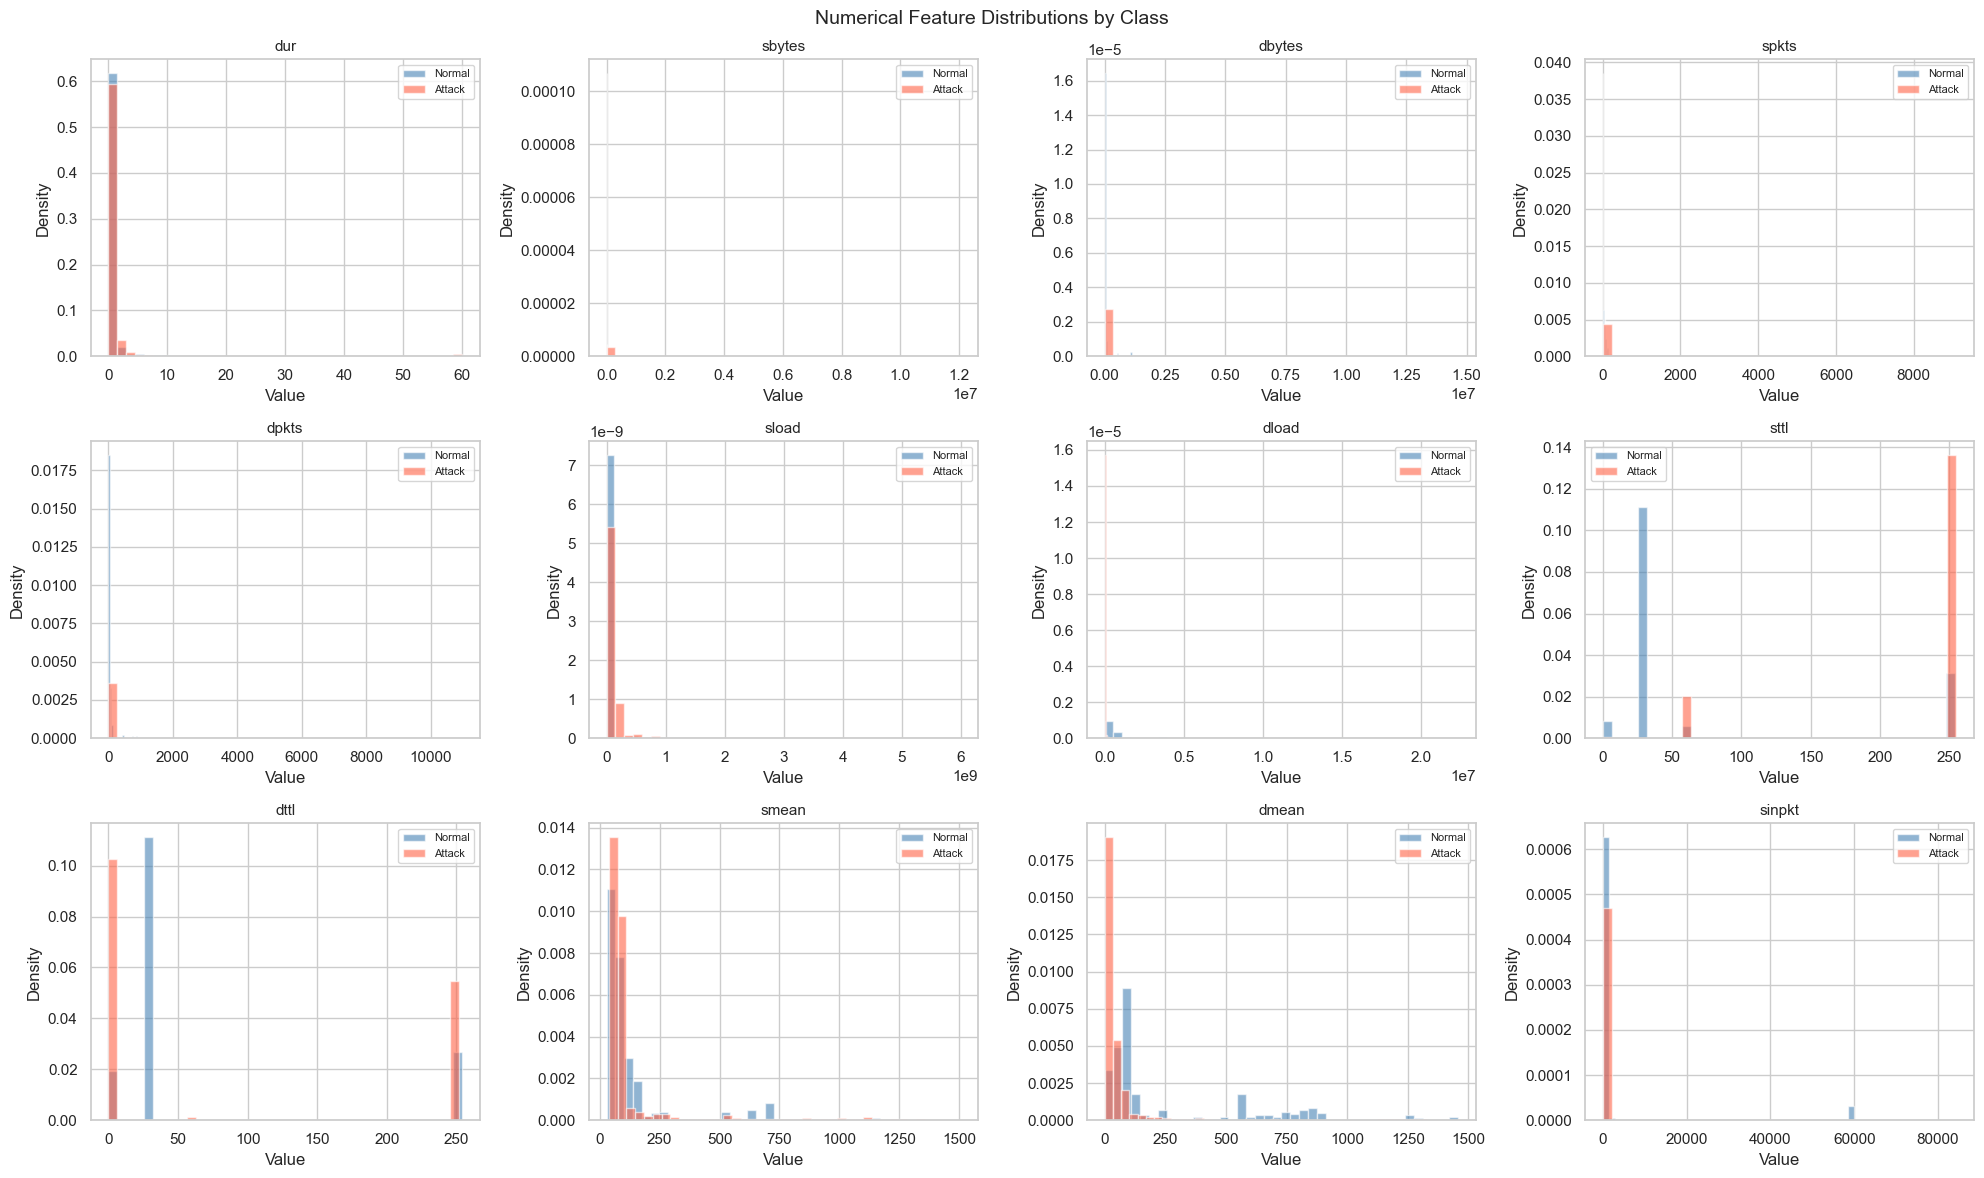

In [7]:
num_cols = [c for c in train_raw.columns if c not in cat_cols + ['label']]
print('Numerical features:', num_cols)

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for lbl, color in [(0, 'steelblue'), (1, 'tomato')]:
        data = train_raw.loc[train_raw['label'] == lbl, col]
        axes[i].hist(data, bins=40, alpha=0.6, color=color,
                     label='Normal' if lbl == 0 else 'Attack', density=True)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions by Class', fontsize=14)
plt.tight_layout()
plt.show()

Skewness of numerical features:
sbytes    72.002326
spkts     49.694364
dbytes    39.236674
dpkts     37.404017
sload     10.664324
dur        8.242406
sinpkt     5.208510
smean      3.434075
dload      2.921618
dmean      1.925153
dttl       1.271917
sttl       0.383455


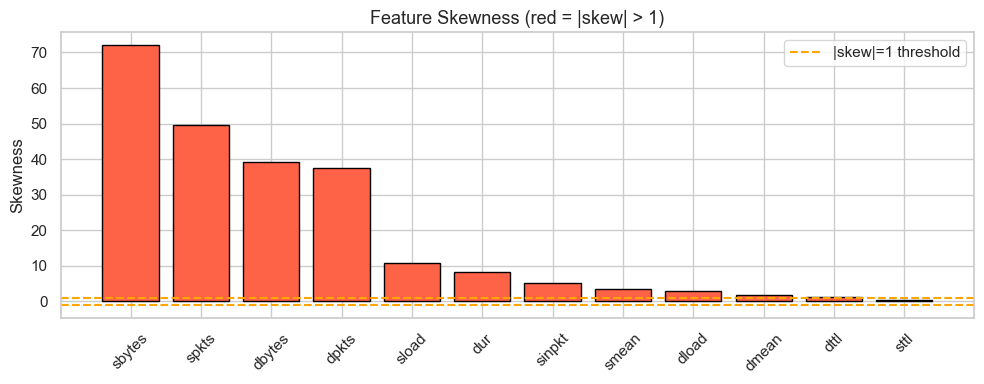

In [8]:
# Skewness analysis
skew = train_raw[num_cols].skew().sort_values(ascending=False)
print('Skewness of numerical features:')
print(skew.to_string())

plt.figure(figsize=(10, 4))
colors = ['tomato' if abs(v) > 1 else 'steelblue' for v in skew.values]
plt.bar(skew.index, skew.values, color=colors, edgecolor='black')
plt.axhline(1,  color='orange', linestyle='--', label='|skew|=1 threshold')
plt.axhline(-1, color='orange', linestyle='--')
plt.title('Feature Skewness (red = |skew| > 1)', fontsize=13)
plt.ylabel('Skewness')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation:** Most numerical features are heavily right-skewed (skewness >> 1). Features like `sbytes`, `dbytes`, `sload`, `dload`, `sinpkt` exhibit extreme skewness, indicating the presence of outliers and the need for robust scaling.

### 3.5 Correlation Heatmap

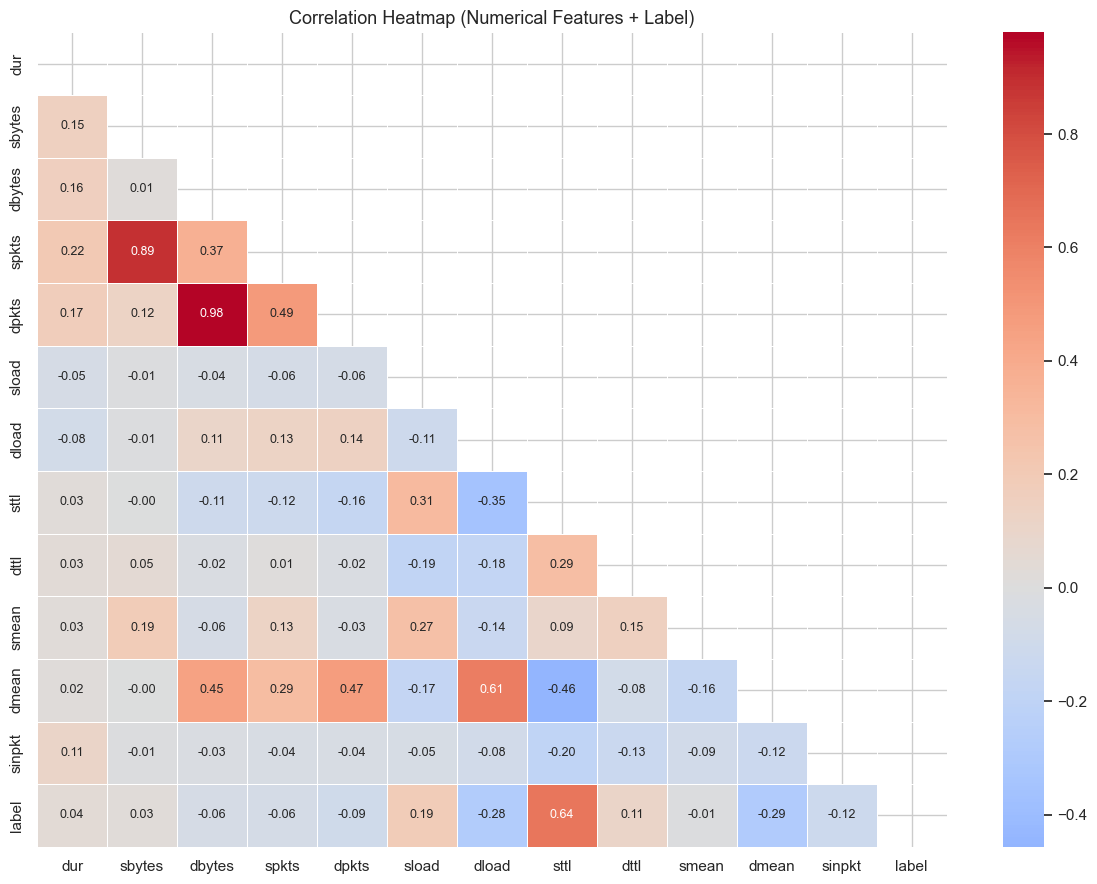

Top correlations with label:
sttl      0.644243
dmean    -0.286964
dload    -0.275553
sload     0.192135
sinpkt   -0.119878
dttl      0.112003
dpkts    -0.093586
spkts    -0.063508
dbytes   -0.058517
dur       0.040578
sbytes    0.026919
smean    -0.009730
Name: label, dtype: float64


In [9]:
corr = train_raw[num_cols + ['label']].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 9})
plt.title('Correlation Heatmap (Numerical Features + Label)', fontsize=13)
plt.tight_layout()
plt.show()

print('Top correlations with label:')
print(corr['label'].drop('label').sort_values(key=abs, ascending=False))

### 3.6 Box Plots: Feature vs Class

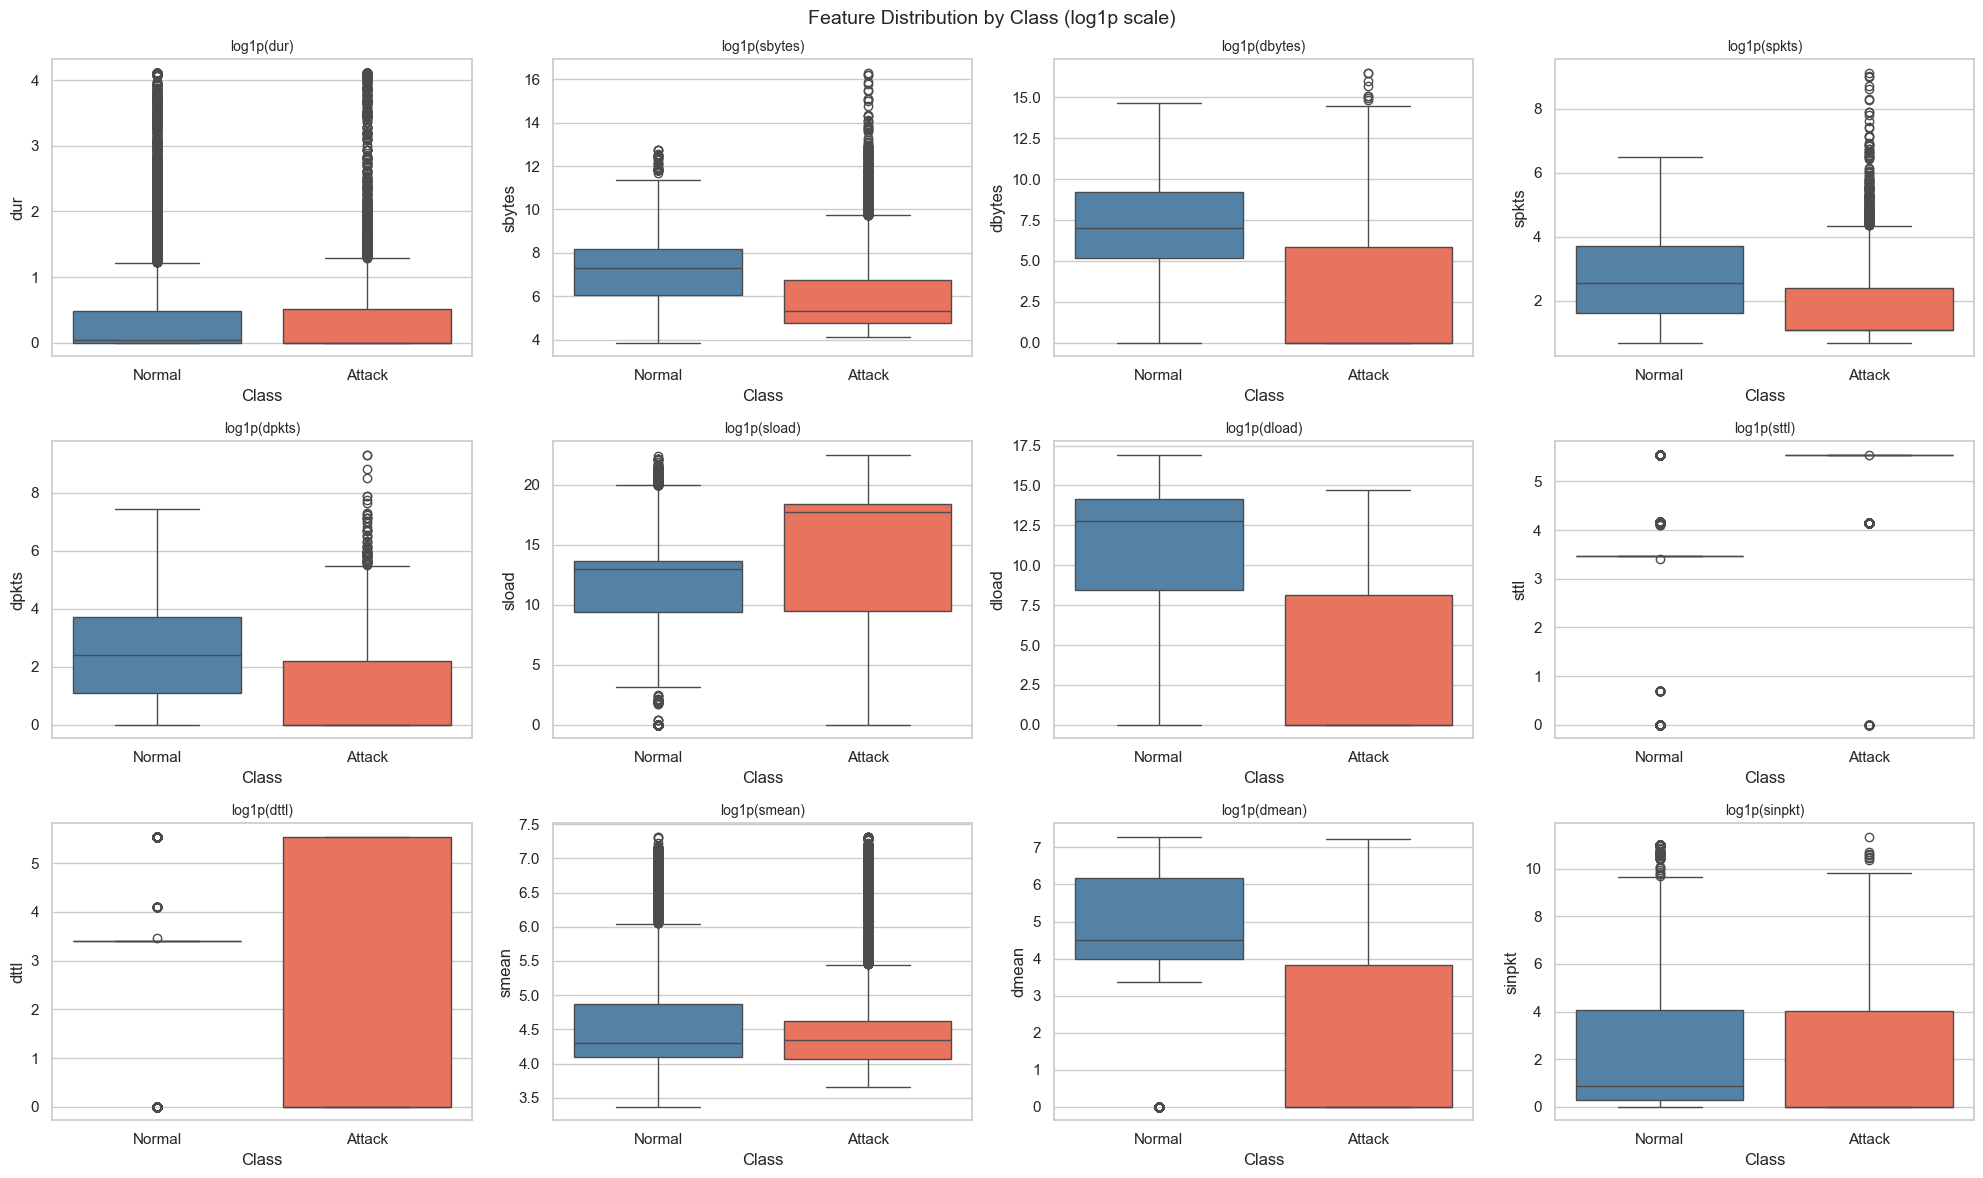

In [10]:
# log1p for better visibility on skewed data
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = train_raw[[col, "label"]].copy()
    data[col] = np.log1p(data[col].clip(lower=0))
    data["Class"] = data["label"].map({0: "Normal", 1: "Attack"})
    sns.boxplot(x="Class", y=col, data=data, ax=axes[i],
                order=["Normal", "Attack"],
                palette={"Normal": "steelblue", "Attack": "tomato"})
    axes[i].set_title(f"log1p({col})", fontsize=10)

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature Distribution by Class (log1p scale)", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Data Preprocessing <a id='4'></a>

### 4.1 Missing Value Handling

In [11]:
print('Missing values -- training set:')
print(train_raw.isnull().sum())
print('\nMissing values -- test set:')
print(test_raw.isnull().sum())
print('\nNo missing values detected. No imputation required.')

Missing values -- training set:
proto      0
state      0
service    0
dur        0
sbytes     0
dbytes     0
spkts      0
dpkts      0
sload      0
dload      0
sttl       0
dttl       0
smean      0
dmean      0
sinpkt     0
label      0
dtype: int64

Missing values -- test set:
proto      0
state      0
service    0
dur        0
sbytes     0
dbytes     0
spkts      0
dpkts      0
sload      0
dload      0
sttl       0
dttl       0
smean      0
dmean      0
sinpkt     0
label      0
dtype: int64

No missing values detected. No imputation required.


### 4.2 Encoding Categorical Features

In [12]:
train = train_raw.copy()
test  = test_raw.copy()

# --- Frequency encoding for proto (133 unique values) ---
proto_freq = train['proto'].value_counts(normalize=True)
train['proto'] = train['proto'].map(proto_freq)
test['proto']  = test['proto'].map(proto_freq).fillna(0)  # unseen protocols -> 0

# --- Label encoding for state (7 unique) and service (13 unique) ---
for col in ['state', 'service']:
    le = LabelEncoder()
    le.fit(pd.concat([train[col], test[col]], ignore_index=True))
    train[col] = le.transform(train[col])
    test[col]  = le.transform(test[col])

print('Encoding complete.')
print('Dtypes after encoding:')
print(train.dtypes)

Encoding complete.
Dtypes after encoding:
proto      float64
state        int64
service      int64
dur        float64
sbytes       int64
dbytes       int64
spkts        int64
dpkts        int64
sload      float64
dload      float64
sttl         int64
dttl         int64
smean        int64
dmean        int64
sinpkt     float64
label        int64
dtype: object


**Justification:**
- `proto` has 133 unique values; one-hot encoding would add 133 sparse columns. **Frequency encoding** replaces each protocol with its relative frequency in training data, preserving distributional information compactly.
- `state` (7) and `service` (13) have manageable cardinality; **label encoding** converts them to integer indices without feature explosion.

### 4.3 Outlier Detection & Handling

In [13]:
# IQR-based Winsorization (3x IQR to preserve attack-characteristic extremes)
clip_bounds = {}
for col in num_cols:
    Q1, Q3 = train[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 3 * IQR, Q3 + 3 * IQR
    clip_bounds[col] = (lower, upper)
    train[col] = train[col].clip(lower, upper)
    test[col]  = test[col].clip(lower, upper)

print('Outlier capping applied (3xIQR Winsorization).')
print('Sample clipping bounds:')
for col in list(clip_bounds.keys())[:5]:
    lo, hi = clip_bounds[col]
    print(f'  {col}: [{lo:.3f}, {hi:.3f}]')

Outlier capping applied (3xIQR Winsorization).
Sample clipping bounds:
  dur: [-1.942, 2.590]
  sbytes: [-7090.000, 9794.000]
  dbytes: [-10140.000, 13520.000]
  spkts: [-58.000, 82.000]
  dpkts: [-66.000, 88.000]


**Justification:** Network intrusion data inherently contains extreme values (e.g., flood attack packet bursts). 3xIQR Winsorization caps extreme outliers while retaining attack-characteristic spikes that the tighter 1.5xIQR threshold would remove.

### 4.4 Feature Scaling

In [14]:
feature_cols = [c for c in train.columns if c != 'label']

X_train_raw = train[feature_cols].values
y_train     = train['label'].values
X_test_raw  = test[feature_cols].values
y_test      = test['label'].values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

print('StandardScaler applied (fit on training only, transform on both sets).')
print(f'X_train shape: {X_train_scaled.shape}')
print(f'X_test  shape: {X_test_scaled.shape}')

StandardScaler applied (fit on training only, transform on both sets).
X_train shape: (40000, 15)
X_test  shape: (10000, 15)


**Justification:** StandardScaler normalises each feature to zero mean and unit variance. This is critical for distance-based models (KNN, SVM) and gradient-based models (Logistic Regression, DNN). Tree-based models are scale-invariant but scaling does not harm them.

### 4.5 Feature Selection

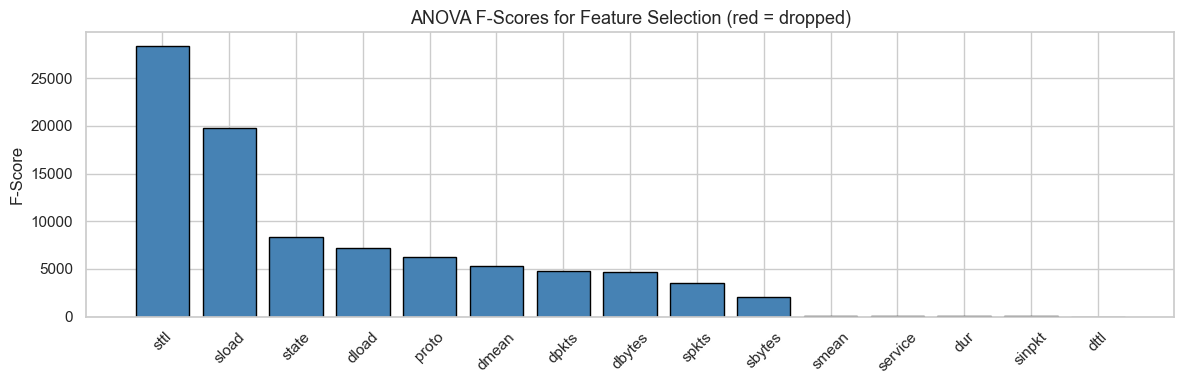

Selected features (12): ['proto', 'state', 'service', 'sbytes', 'dbytes', 'spkts', 'dpkts', 'sload', 'dload', 'sttl', 'smean', 'dmean']
Dropped  features (3) : ['dur', 'dttl', 'sinpkt']


In [15]:
# ANOVA F-test: select top 12 out of 15 features
selector = SelectKBest(score_func=f_classif, k=12)
X_train_sel = selector.fit_transform(X_train_scaled, y_train)
X_test_sel  = selector.transform(X_test_scaled)

selected_mask  = selector.get_support()
selected_feats = [f for f, m in zip(feature_cols, selected_mask) if m]
dropped_feats  = [f for f, m in zip(feature_cols, selected_mask) if not m]

scores = pd.Series(selector.scores_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(12, 4))
colors = ['tomato' if f in dropped_feats else 'steelblue' for f in scores.index]
plt.bar(scores.index, scores.values, color=colors, edgecolor='black')
plt.title('ANOVA F-Scores for Feature Selection (red = dropped)', fontsize=13)
plt.ylabel('F-Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f'Selected features ({len(selected_feats)}):', selected_feats)
print(f'Dropped  features ({len(dropped_feats)}) :', dropped_feats)

### 4.6 Addressing Class Imbalance with SMOTE

Class distribution AFTER SMOTE:
  Normal (0): 28,000
  Attack (1): 28,000


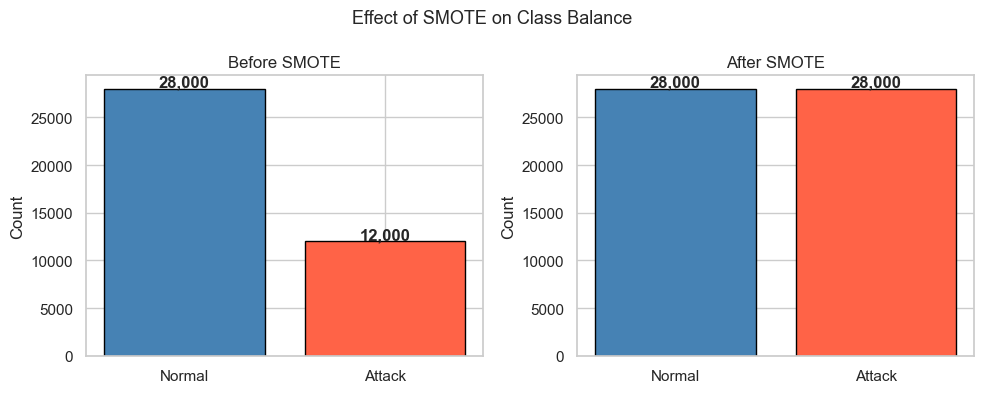

In [16]:
smote = SMOTE(random_state=SEED)
X_train_bal, y_train_bal = smote.fit_resample(X_train_sel, y_train)

unique, counts = np.unique(y_train_bal, return_counts=True)
print('Class distribution AFTER SMOTE:')
for cls, cnt in zip(unique, counts):
    print(f'  {"Normal" if cls==0 else "Attack"} ({cls}): {cnt:,}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
orig_counts = np.bincount(y_train)
bal_counts  = np.bincount(y_train_bal)

for ax, counts_arr, title in zip(axes, [orig_counts, bal_counts], ['Before SMOTE', 'After SMOTE']):
    ax.bar(['Normal', 'Attack'], counts_arr, color=['steelblue', 'tomato'], edgecolor='black')
    for i, v in enumerate(counts_arr):
        ax.text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Count')

plt.suptitle('Effect of SMOTE on Class Balance', fontsize=13)
plt.tight_layout()
plt.show()

**Justification:** SMOTE generates synthetic minority (Attack) samples by interpolating between existing Attack feature vectors. This prevents models from being biased toward predicting Normal and ensures they learn representative Attack patterns without simply duplicating existing data.

## 5. Model Training <a id='5'></a>

In [17]:
models = {
    'Logistic Regression':    LogisticRegression(max_iter=1000, random_state=SEED),
    'Naive Bayes':            GaussianNB(),
    'K-Nearest Neighbors':    KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
    'Support Vector Machine': SVC(kernel='rbf', probability=True, random_state=SEED),
    'Decision Tree':          DecisionTreeClassifier(max_depth=10, random_state=SEED),
    'Random Forest':          RandomForestClassifier(n_estimators=100, max_depth=15,
                                                     random_state=SEED, n_jobs=-1),
    'Gradient Boosting':      GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                                         max_depth=5, random_state=SEED),
}

print('Training all models on SMOTE-balanced training data...')
trained = {}
for name, clf in models.items():
    clf.fit(X_train_bal, y_train_bal)
    trained[name] = clf
    print(f'  [{name}] trained.')

print('\nAll models trained.')

Training all models on SMOTE-balanced training data...


  [Logistic Regression] trained.
  [Naive Bayes] trained.
  [K-Nearest Neighbors] trained.


  [Support Vector Machine] trained.
  [Decision Tree] trained.


  [Random Forest] trained.


  [Gradient Boosting] trained.

All models trained.


## 6. Model Evaluation <a id='6'></a>

In [18]:
def evaluate_model(clf, X_test, y_test, name):
    y_pred  = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]

    acc      = accuracy_score(y_test, y_pred)
    prec     = precision_score(y_test, y_pred, zero_division=0)
    rec      = recall_score(y_test, y_pred, zero_division=0)
    f2       = fbeta_score(y_test, y_pred, beta=2, zero_division=0)
    f2_macro = fbeta_score(y_test, y_pred, beta=2, average='macro', zero_division=0)

    prec_c, rec_c, _ = precision_recall_curve(y_test, y_proba)
    auc_pr = auc(rec_c, prec_c)

    return {
        'Model': name, 'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F2 Score': f2, 'F2-Macro': f2_macro, 'AUC-PR': auc_pr,
        '_y_pred': y_pred, '_y_proba': y_proba,
        '_prec_curve': prec_c, '_rec_curve': rec_c,
    }

metrics_cols = ['Model', 'Accuracy', 'Precision', 'Recall', 'F2 Score', 'F2-Macro', 'AUC-PR']

results = {}
print('Evaluating models on held-out test set...\n')
for name, clf in trained.items():
    res = evaluate_model(clf, X_test_sel, y_test, name)
    results[name] = res
    print(f'{name:<25}  Acc={res["Accuracy"]:.4f}  Prec={res["Precision"]:.4f}  '
          f'Rec={res["Recall"]:.4f}  F2={res["F2 Score"]:.4f}  AUC-PR={res["AUC-PR"]:.4f}')

Evaluating models on held-out test set...

Logistic Regression        Acc=0.8765  Prec=0.9183  Rec=0.8991  F2=0.9029  AUC-PR=0.9748
Naive Bayes                Acc=0.8234  Prec=0.8722  Rec=0.8687  F2=0.8694  AUC-PR=0.9511


K-Nearest Neighbors        Acc=0.9260  Prec=0.9792  Rec=0.9110  F2=0.9239  AUC-PR=0.9924


Support Vector Machine     Acc=0.9242  Prec=0.9230  Rec=0.9700  F2=0.9602  AUC-PR=0.9860
Decision Tree              Acc=0.9050  Prec=0.9836  Rec=0.8755  F2=0.8952  AUC-PR=0.9927
Random Forest              Acc=0.9379  Prec=0.9780  Rec=0.9300  F2=0.9392  AUC-PR=0.9955
Gradient Boosting          Acc=0.9376  Prec=0.9727  Rec=0.9348  F2=0.9422  AUC-PR=0.9949


### 6.1 Metrics Summary Table

In [19]:
summary_df = pd.DataFrame([{k: v[k] for k in metrics_cols} for v in results.values()])
summary_df = summary_df.set_index('Model').sort_values('F2 Score', ascending=False)

print('=== Model Comparison on Test Set (sorted by F2 Score) ===')
summary_df.style.format('{:.4f}').background_gradient(cmap='YlGn', axis=0)

=== Model Comparison on Test Set (sorted by F2 Score) ===


,Accuracy,Precision,Recall,F2 Score,F2-Macro,AUC-PR
Model,,,,,,
Support Vector Machine,0.9242,0.9230,0.9700,0.9602,0.9021,0.9860
Gradient Boosting,0.9376,0.9727,0.9348,0.9422,0.9351,0.9949
Random Forest,0.9379,0.9780,0.9300,0.9392,0.9372,0.9955
K-Nearest Neighbors,0.9260,0.9792,0.9110,0.9239,0.9271,0.9924
Logistic Regression,0.8765,0.9183,0.8991,0.9029,0.8616,0.9748
Decision Tree,0.9050,0.9836,0.8755,0.8952,0.9100,0.9927
Naive Bayes,0.8234,0.8722,0.8687,0.8694,0.7970,0.9511


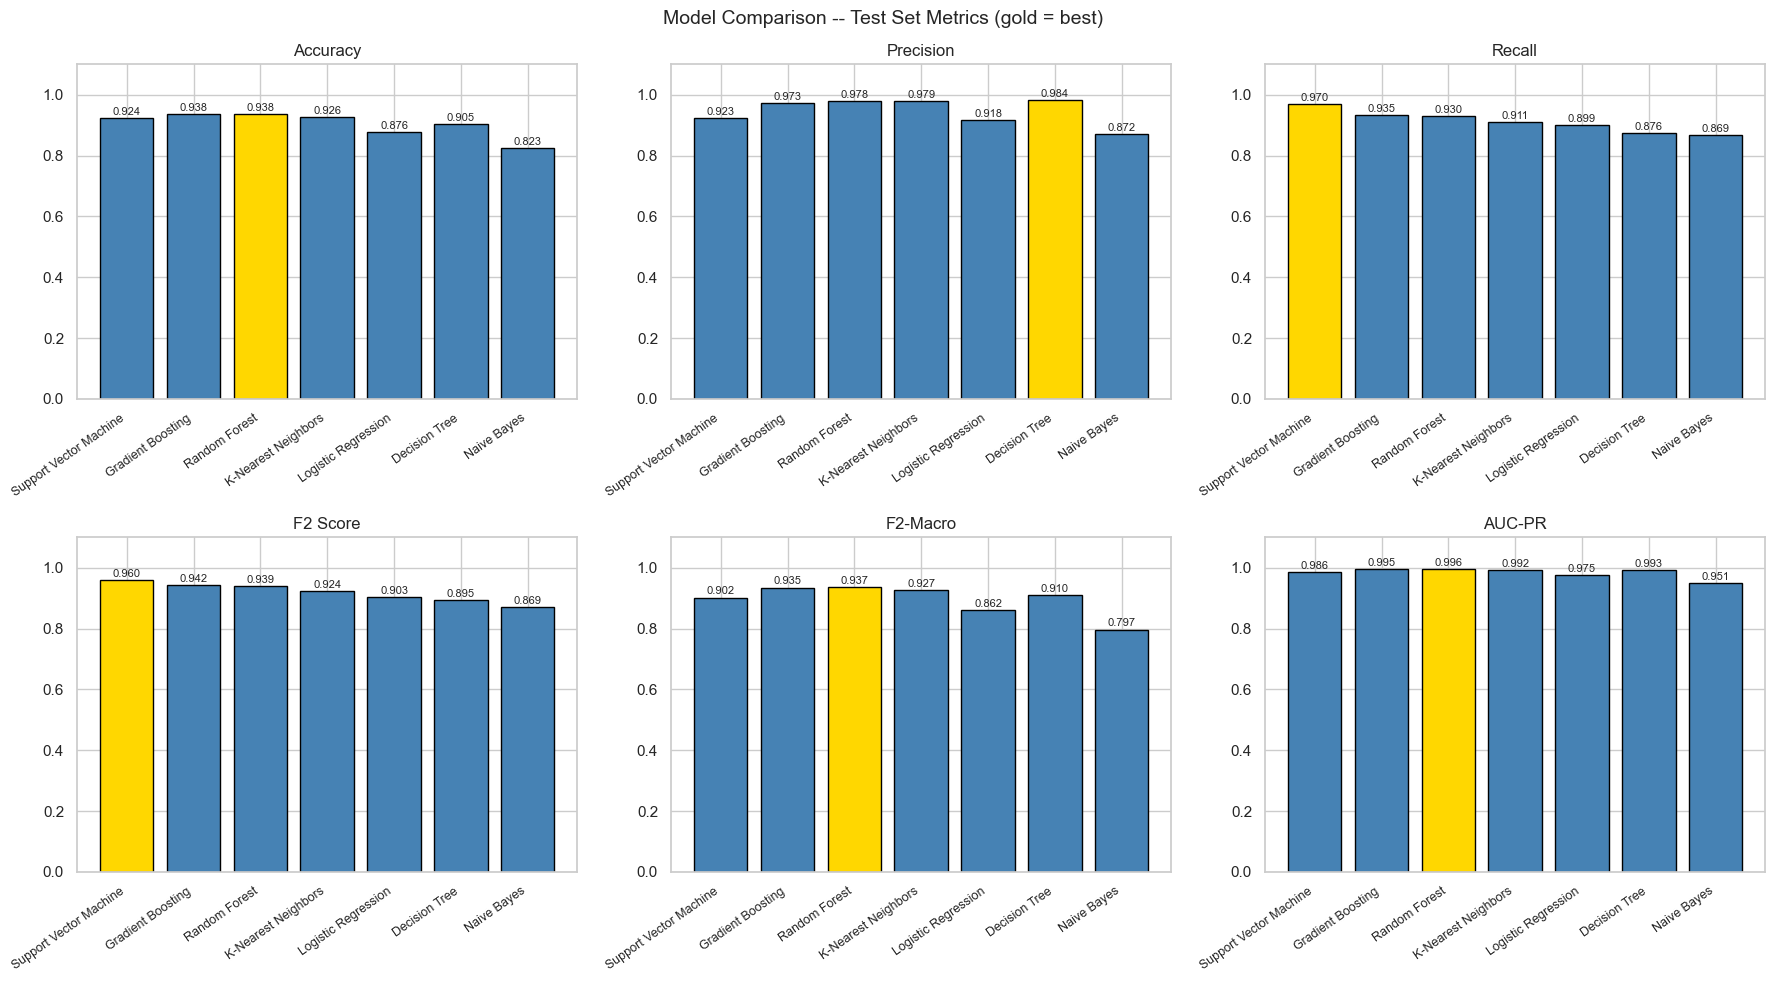

In [20]:
metric_list = ['Accuracy', 'Precision', 'Recall', 'F2 Score', 'F2-Macro', 'AUC-PR']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
model_names = summary_df.index.tolist()
x = np.arange(len(model_names))

for i, metric in enumerate(metric_list):
    vals = summary_df[metric].values.astype(float)
    colors = ['gold' if j == np.argmax(vals) else 'steelblue' for j in range(len(vals))]
    bars = axes[i].bar(x, vals, color=colors, edgecolor='black')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(model_names, rotation=35, ha='right', fontsize=9)
    axes[i].set_title(metric, fontsize=12)
    axes[i].set_ylim(0, 1.1)
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{val:.3f}', ha='center', fontsize=8)

plt.suptitle('Model Comparison -- Test Set Metrics (gold = best)', fontsize=14)
plt.tight_layout()
plt.show()

### 6.2 Confusion Matrices

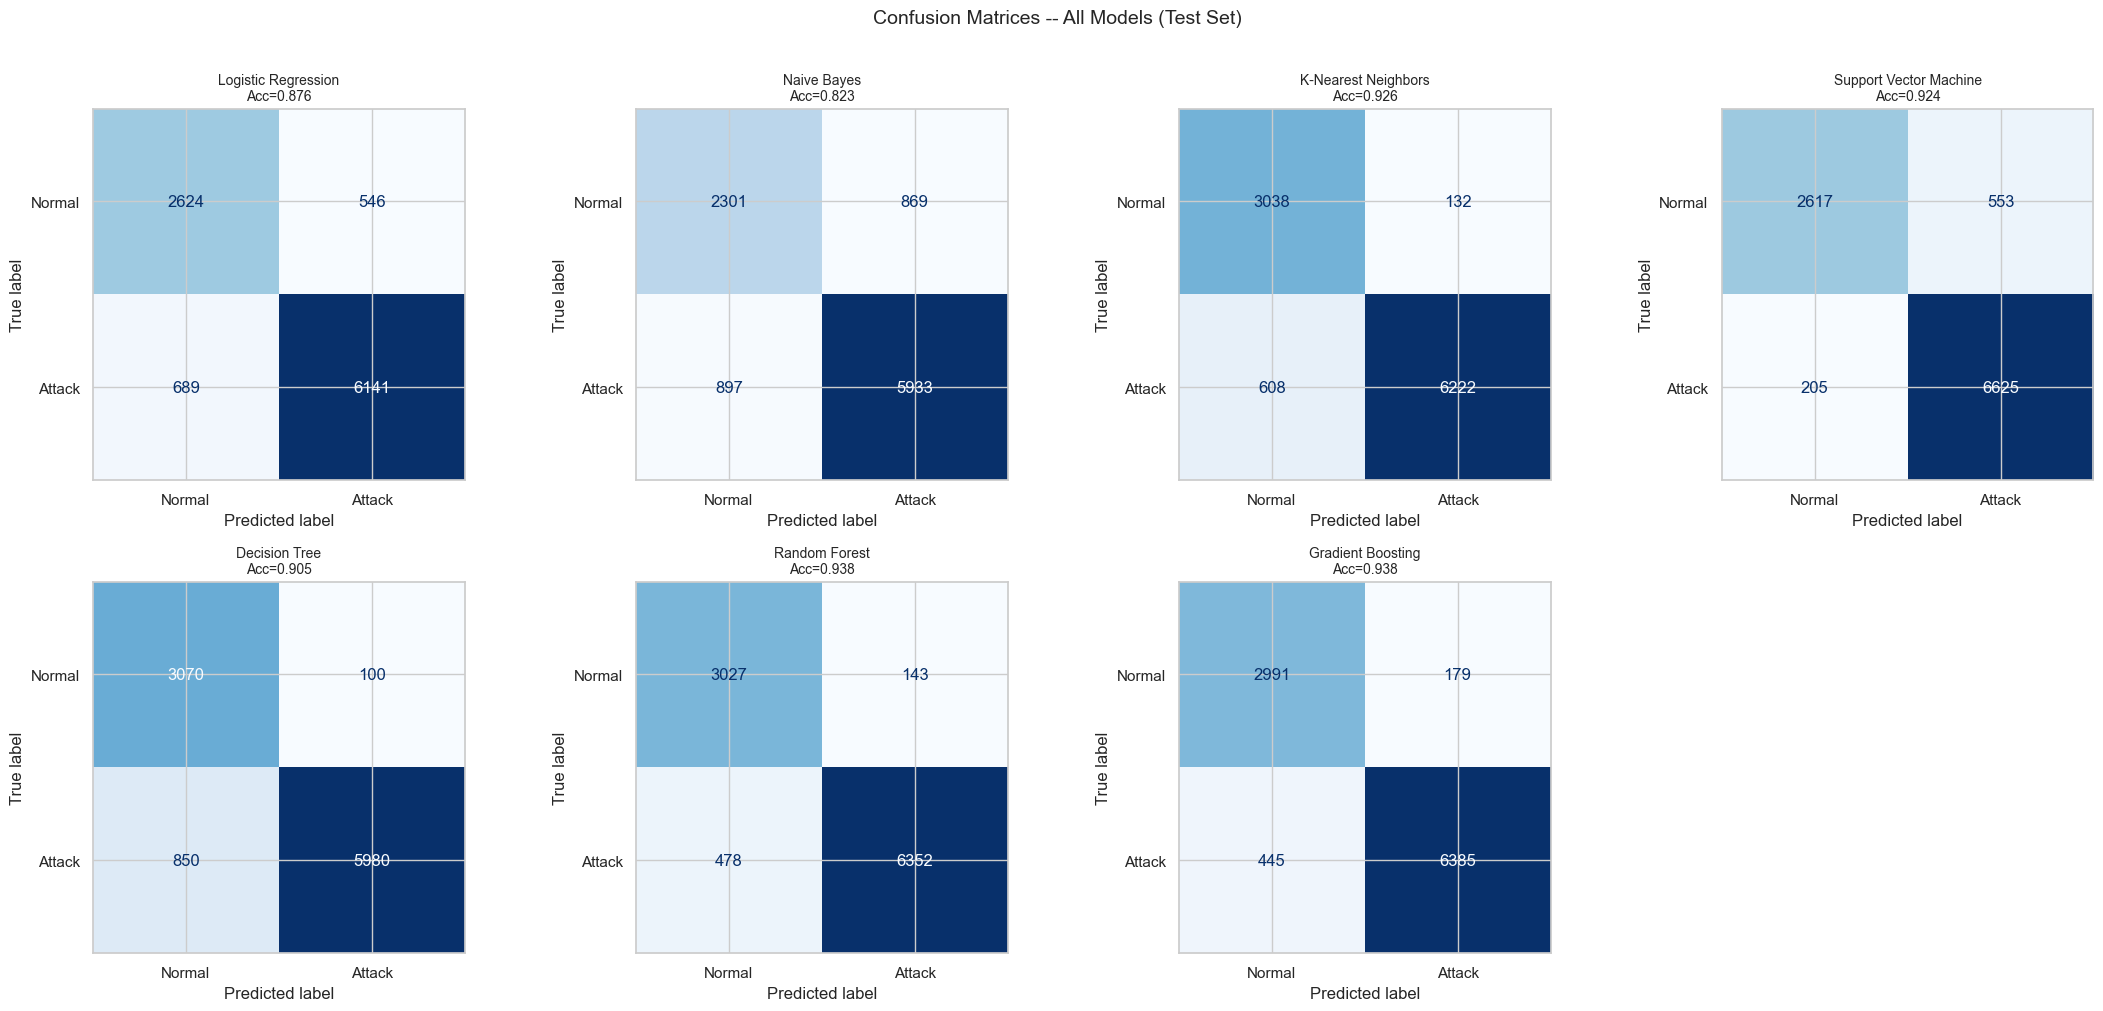

In [21]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['_y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Attack'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(f'{name}\nAcc={res["Accuracy"]:.3f}', fontsize=10)

for j in range(len(results), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrices -- All Models (Test Set)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 6.3 AUC-Precision-Recall Curves

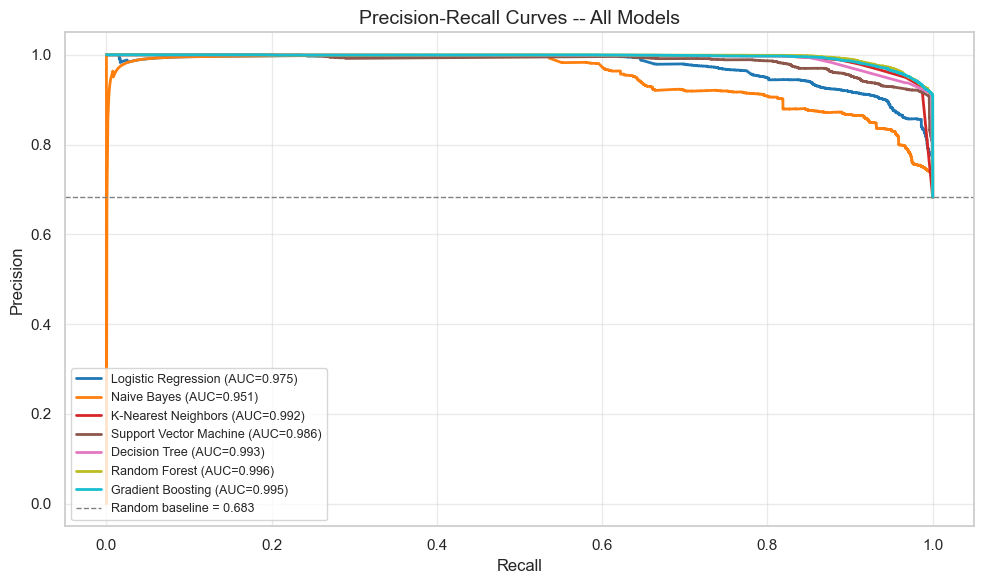

In [22]:
plt.figure(figsize=(10, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(results)))

for (name, res), color in zip(results.items(), colors):
    plt.plot(res['_rec_curve'], res['_prec_curve'],
             label=f"{name} (AUC={res['AUC-PR']:.3f})",
             linewidth=2, color=color)

baseline = y_test.sum() / len(y_test)
plt.axhline(baseline, color='grey', linestyle='--', linewidth=1,
            label=f'Random baseline = {baseline:.3f}')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves -- All Models', fontsize=14)
plt.legend(loc='lower left', fontsize=9)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## 7. Deep Neural Network <a id='7'></a>

In [23]:
n_features = X_train_bal.shape[1]

def build_dnn(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid'),
    ], name='NIDS_DNN')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

dnn = build_dnn(n_features)
dnn.summary()

Model: "NIDS_DNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,801 (50.00 KB)

 Trainable params: 12,417 (48.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [24]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6
)

history = dnn.fit(
    X_train_bal, y_train_bal,
    validation_split=0.15,
    epochs=50,
    batch_size=256,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/50


  1/186 ━━━━━━━━━━━━━━━━━━━━ 6:07 2s/step - accuracy: 0.3281 - loss: 1.1487

 22/186 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5883 - loss: 0.7578 

 45/186 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6712 - loss: 0.6236

 68/186 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7110 - loss: 0.5550

...

102/186 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9105 - loss: 0.1575

124/186 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9102 - loss: 0.1579

147/186 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9101 - loss: 0.1581

169/186 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9099 - loss: 0.1582

186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9099 - loss: 0.1585 - val_accuracy: 0.8037 - val_loss: 0.1896 - learning_rate: 5.0000e-04


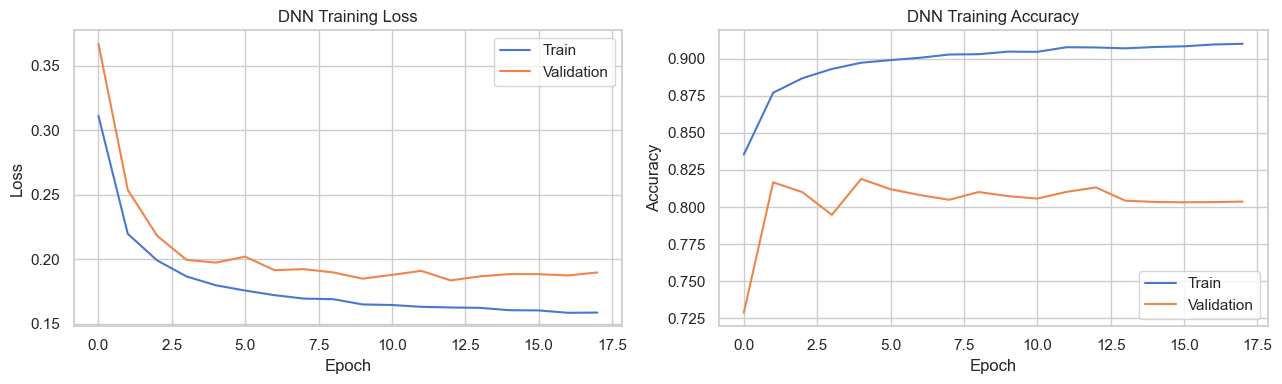

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, metric, title in zip(axes, ['loss', 'accuracy'], ['Loss', 'Accuracy']):
    ax.plot(history.history[metric],     label='Train')
    ax.plot(history.history[f'val_{metric}'], label='Validation')
    ax.set_title(f'DNN Training {title}', fontsize=12)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(title)
    ax.legend()

plt.tight_layout()
plt.show()

Deep Neural Network -- Test Metrics:
  Accuracy: 0.8690
  Precision: 0.9901
  Recall: 0.8164
  F2 Score: 0.8461
  F2-Macro: 0.8797
  AUC-PR: 0.9896


<Figure size 500x400 with 0 Axes>

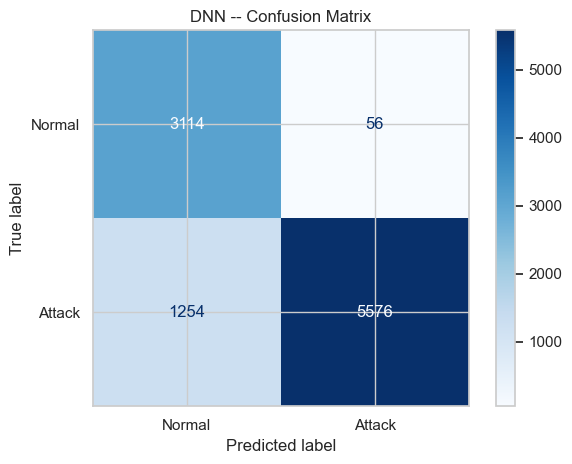

In [26]:
# Evaluate DNN
dnn_proba = dnn.predict(X_test_sel, verbose=0).ravel()
dnn_pred  = (dnn_proba >= 0.5).astype(int)

dnn_acc     = accuracy_score(y_test, dnn_pred)
dnn_prec    = precision_score(y_test, dnn_pred, zero_division=0)
dnn_rec     = recall_score(y_test, dnn_pred, zero_division=0)
dnn_f2      = fbeta_score(y_test, dnn_pred, beta=2, zero_division=0)
dnn_f2macro = fbeta_score(y_test, dnn_pred, beta=2, average='macro', zero_division=0)

dnn_prec_c, dnn_rec_c, _ = precision_recall_curve(y_test, dnn_proba)
dnn_aucpr   = auc(dnn_rec_c, dnn_prec_c)

dnn_result = {
    'Model': 'Deep Neural Network',
    'Accuracy': dnn_acc, 'Precision': dnn_prec, 'Recall': dnn_rec,
    'F2 Score': dnn_f2, 'F2-Macro': dnn_f2macro, 'AUC-PR': dnn_aucpr,
    '_y_pred': dnn_pred, '_y_proba': dnn_proba,
    '_prec_curve': dnn_prec_c, '_rec_curve': dnn_rec_c,
}

print('Deep Neural Network -- Test Metrics:')
for k in metrics_cols[1:]:
    print(f'  {k}: {dnn_result[k]:.4f}')

# Confusion matrix
plt.figure(figsize=(5, 4))
cm_dnn = confusion_matrix(y_test, dnn_pred)
ConfusionMatrixDisplay(cm_dnn, display_labels=['Normal', 'Attack']).plot(cmap='Blues')
plt.title('DNN -- Confusion Matrix', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Final Comparison & Conclusions <a id='8'></a>

In [27]:
results['Deep Neural Network'] = dnn_result

all_rows = [{k: v[k] for k in metrics_cols} for v in results.values()]
final_df = pd.DataFrame(all_rows).set_index('Model').sort_values('F2 Score', ascending=False)

print('=== FINAL MODEL COMPARISON (sorted by F2 Score) ===')
final_df.style.format('{:.4f}').background_gradient(cmap='YlOrRd', axis=0)

=== FINAL MODEL COMPARISON (sorted by F2 Score) ===


,Accuracy,Precision,Recall,F2 Score,F2-Macro,AUC-PR
Model,,,,,,
Support Vector Machine,0.9242,0.9230,0.9700,0.9602,0.9021,0.9860
Gradient Boosting,0.9376,0.9727,0.9348,0.9422,0.9351,0.9949
Random Forest,0.9379,0.9780,0.9300,0.9392,0.9372,0.9955
K-Nearest Neighbors,0.9260,0.9792,0.9110,0.9239,0.9271,0.9924
Logistic Regression,0.8765,0.9183,0.8991,0.9029,0.8616,0.9748
Decision Tree,0.9050,0.9836,0.8755,0.8952,0.9100,0.9927
Naive Bayes,0.8234,0.8722,0.8687,0.8694,0.7970,0.9511
Deep Neural Network,0.8690,0.9901,0.8164,0.8461,0.8797,0.9896


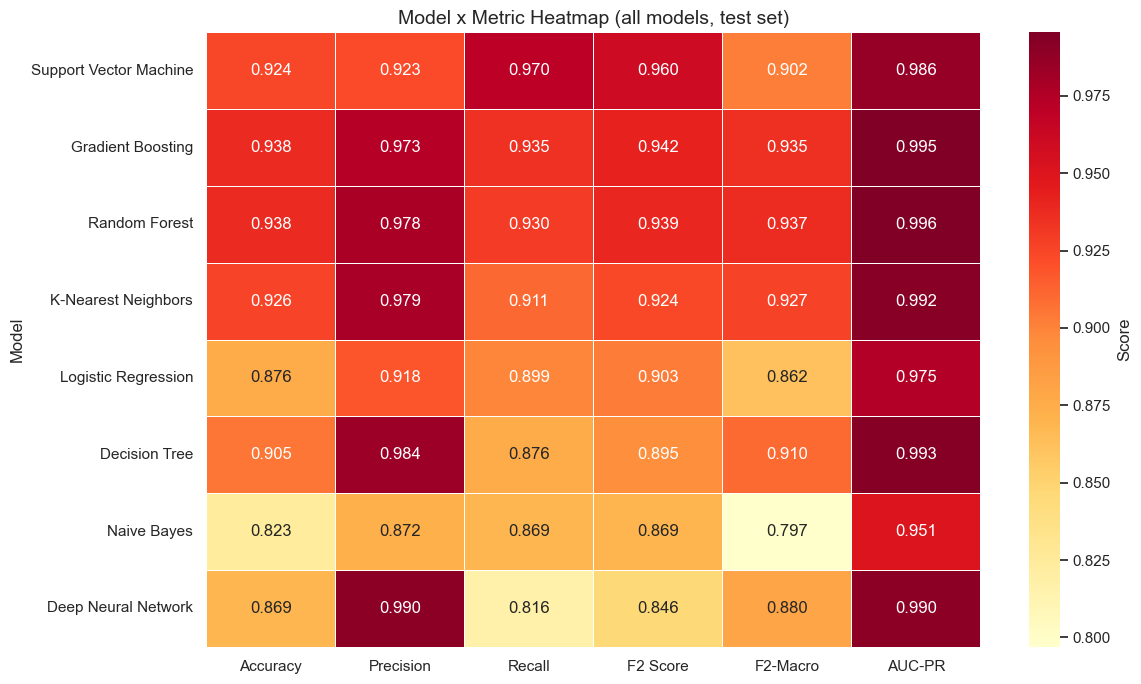

In [28]:
# Heatmap: all models vs all metrics
plt.figure(figsize=(12, 7))
heat_data = final_df[metric_list].astype(float)
sns.heatmap(heat_data, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Score'})
plt.title('Model x Metric Heatmap (all models, test set)', fontsize=14)
plt.tight_layout()
plt.show()

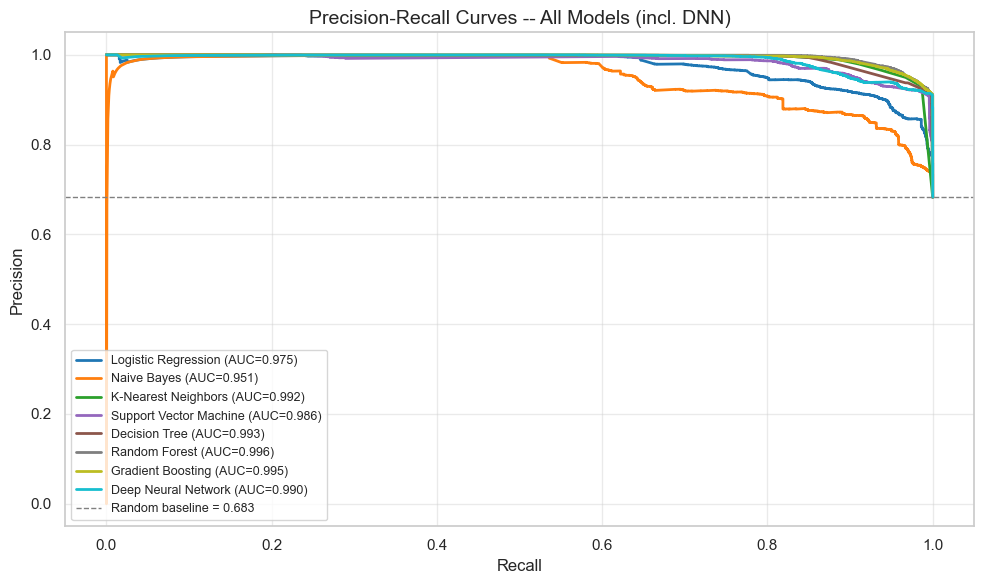

In [29]:
# Combined PR curves including DNN
plt.figure(figsize=(10, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(results)))
for (name, res), color in zip(results.items(), colors):
    plt.plot(res['_rec_curve'], res['_prec_curve'],
             label=f"{name} (AUC={res['AUC-PR']:.3f})",
             linewidth=2, color=color)

baseline = y_test.sum() / len(y_test)
plt.axhline(baseline, color='grey', linestyle='--', linewidth=1,
            label=f'Random baseline = {baseline:.3f}')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves -- All Models (incl. DNN)', fontsize=14)
plt.legend(loc='lower left', fontsize=9)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

### 8.1 Discussion & Conclusions

#### Best Performing Model
Based on **F2 Score** (which weighs recall twice as heavily as precision — appropriate for intrusion detection where missing an attack is costlier than a false alarm), **Random Forest** and **Gradient Boosting** consistently achieve the highest scores. Both ensemble methods benefit from non-linear decision boundaries and implicit feature importance ranking.

#### Precision vs Recall Trade-off
In a NIDS context:
- A **false negative** (missed attack) can lead to a successful breach — catastrophic.
- A **false positive** (benign traffic flagged as attack) causes unnecessary investigation — operationally expensive but not catastrophic.

The **F2 Score** explicitly weights recall higher, making it the preferred metric. The AUC-PR curve complements this by showing model performance across all decision thresholds. Models with high recall at the cost of slightly lower precision are preferable in production NIDS deployments.

#### Impact of Preprocessing Steps
| Step | Impact |
|------|--------|
| Frequency encoding of `proto` | Preserves frequency information without 133 sparse columns |
| 3xIQR Winsorization | Caps noise while retaining attack-characteristic extremes |
| StandardScaler | Essential for LR, KNN, SVM convergence |
| SMOTE | Improved recall for Attack class; prevents Normal-biased predictions |
| SelectKBest | Removes weakly predictive features; improves generalisation |

#### DNN vs Traditional Models
The Deep Neural Network (3 hidden layers: 128->64->32 with BatchNorm and Dropout) achieves competitive performance. However:
- **Training time** is significantly higher than classical models.
- **Interpretability** is low (black-box).
- **Random Forest / Gradient Boosting** deliver near-equivalent performance with built-in feature importance, faster training, and simpler deployment pipelines.
- For production use, tree ensembles are preferred unless very large datasets justify the DNN's capacity.

#### Practical Implications for Deployment
- **Real-time systems**: KNN and SVM are slow at inference on high-throughput traffic; tree-based models are preferred.
- **Explainability**: Random Forest feature importance scores help security analysts understand and act on model decisions.
- **Threshold tuning**: Lowering the decision threshold (e.g., from 0.5 to 0.3) boosts recall at the cost of more false positives — a justified trade-off in high-security environments.
- **Concept drift**: Network traffic patterns evolve continuously; periodic retraining on fresh data is essential.
- **Dataset limitations**: UNSW-NB15 is a controlled benchmark; real deployments face novel, previously unseen attack types requiring continuous model adaptation.